<a href="https://colab.research.google.com/github/Akobabs/IRIS-FINGERPRINT-PSO-SVM/blob/main/Run1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
=======================================================================
MULTIMODAL BIOMETRIC RECOGNITION SYSTEM
Iris + Fingerprint | Feature-Level Fusion | PCA + PSO-SVM
=======================================================================

FIXES APPLIED (vs script1.ipynb):
  1. Iris glob pattern was hard-coded to "aeval*.bmp" / "aevar*.bmp"
     → Each subject uses a DIFFERENT name prefix (subject 1: aeval/aevar,
       subject 2: bryanl/bryanr, subject 3: chingycl/chingycr, etc.)
     → FIX: Use wildcard "*.bmp" to match any filename, exclude desktop.ini

  2. IndexError: tuple index out of range in load_chimeric_dataset
     → When no samples are loaded, X is shape (0,) — a 1-D array.
       X.shape[1] crashes because there is no dimension 1.
     → FIX: Guard with early return on empty list + use np.vstack
       to always guarantee a 2-D array.

  3. Fingerprint glob was "*.BMP" (uppercase) — Linux/Colab is case-sensitive.
     → FIX: Use case-insensitive helper that covers both .bmp and .BMP
=======================================================================
"""

# CELL 0: Mount Google Drive (Colab only)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# CELL 1: Install Dependencies & Imports


In [2]:
!pip install pyswarms scikit-learn opencv-python-headless tqdm matplotlib numpy

import os
import re
import glob
import fnmatch
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
import pyswarms as ps

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("Drive mounted. TF version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 9.7 MB/s eta 0:00:00
Drive mounted. TF version: 2.20.0


# CELL 2: Configuration — UPDATE BASE_DIR TO MATCH YOUR DRIVE LOCATION


In [3]:
BASE_DIR = "/content/drive/MyDrive/IRIS-FINGERPRINT-PSO-SVM/Data"

# --- Primary Homologous Dataset ---
HOMOLOGOUS_DIR = os.path.join(BASE_DIR, "IRIS and FINGERPRINT DATASET")
NUM_SUBJECTS    = 45   # Subjects 1 – 45

# --- Secondary Chimeric Dataset ---
MMU_IRIS_DIR = os.path.join(
    BASE_DIR,
    "Face_Fingerprint_iris_recognition_dataset",
    "Iris_Recognition",
    "MMU-Iris-Database"
)
L3SF_FP_DIR = os.path.join(
    BASE_DIR,
    "Face_Fingerprint_iris_recognition_dataset",
    "Finger_print_recognition",
    "L3SF_V2", "L3-SF"
)
L3SF_SUBFOLDERS = ["R1", "R2", "R3", "R4", "R5"]  # 5 repetitions

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Configuration loaded.")
print(f"  Homologous dir : {HOMOLOGOUS_DIR}")
print(f"  MMU Iris dir   : {MMU_IRIS_DIR}")
print(f"  L3-SF FP dir   : {L3SF_FP_DIR}")

Configuration loaded.
  Homologous dir : /content/drive/MyDrive/IRIS-FINGERPRINT-PSO-SVM/Data/IRIS and FINGERPRINT DATASET
  MMU Iris dir   : /content/drive/MyDrive/IRIS-FINGERPRINT-PSO-SVM/Data/Face_Fingerprint_iris_recognition_dataset/Iris_Recognition/MMU-Iris-Database
  L3-SF FP dir   : /content/drive/MyDrive/IRIS-FINGERPRINT-PSO-SVM/Data/Face_Fingerprint_iris_recognition_dataset/Finger_print_recognition/L3SF_V2/L3-SF


# CELL 3: Feature Extractor — MobileNetV2 (pretrained, no top)


In [4]:
print("Loading MobileNetV2 feature extractor …")
_feat_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
_feat_model.trainable = False
print(f"Feature vector size: {_feat_model.output_shape[-1]}")   # 1280-D


def extract_features(bgr_img: np.ndarray) -> np.ndarray:
    """
    Takes a BGR image (OpenCV), resizes to 224x224, and extracts a
    1280-D feature vector using the frozen MobileNetV2 backbone.
    """
    if bgr_img is None:
        return None
    rgb  = cv2.cvtColor(cv2.resize(bgr_img, (224, 224)), cv2.COLOR_BGR2RGB)
    arr  = np.expand_dims(rgb.astype(np.float32), axis=0)
    arr  = preprocess_input(arr)          # MobileNetV2 preprocessing
    feat = _feat_model.predict(arr, verbose=0)
    return feat.flatten()                  # shape: (1280,)


Loading MobileNetV2 feature extractor …


/tmp/ipykernel_3926/974643352.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  _feat_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Feature vector size: 1280


# CELL 4: Image Preprocessing Helpers


In [5]:
def preprocess_iris_img(path: str) -> np.ndarray:
    """
    Read a BMP/PNG iris image and apply CLAHE for contrast enhancement.
    Returns a 3-channel BGR image ready for the CNN extractor.
    """
    img = cv2.imread(path)
    if img is None:
        print(f"  [WARN] Cannot read iris image: {path}")
        return None
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)


def preprocess_fp_img(path: str) -> np.ndarray:
    """
    Read a BMP/PNG fingerprint image and enhance ridges with
    adaptive thresholding.
    Returns a 3-channel BGR image ready for the CNN extractor.
    """
    img = cv2.imread(path)
    if img is None:
        print(f"  [WARN] Cannot read fingerprint image: {path}")
        return None
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    enhanced = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)


# =====================================================================
# UTILITY: Case-insensitive glob helper (fixes Linux/Colab case issue)
# =====================================================================
def glob_case_insensitive(directory: str, pattern: str) -> list:
    """
    Return sorted list of file paths in `directory` that match `pattern`
    case-insensitively. Works on both Windows and Linux/Colab.
    """
    if not os.path.isdir(directory):
        return []
    matched = [
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if fnmatch.fnmatch(f.lower(), pattern.lower())
        and not f.lower().startswith("desktop")   # skip desktop.ini
    ]
    return sorted(matched)

# CELL 5: Data Loader — Primary Homologous Dataset


"""
Directory structure (confirmed):
  IRIS and FINGERPRINT DATASET/
    {subject_id}/           ← e.g. "1", "2", … "45"
      Fingerprint/
        {id}__M_Left_index_finger.BMP   (10 .BMP files total)
        …
      left/
        {name}l1.bmp  {name}l2.bmp  …  {name}l5.bmp   ← ANY prefix
      right/
        {name}r1.bmp  {name}r2.bmp  …  {name}r5.bmp   ← ANY prefix

BUG FIX: Iris filenames use a DIFFERENT prefix per subject
  (e.g. "aeval" for subject 1, "bryanl" for subject 2, "chingycl" for 3…)
  → Use wildcard "*.bmp" instead of "aeval*.bmp" / "aevar*.bmp"
"""

In [6]:
def load_homologous_dataset(data_dir: str, num_subjects: int = 45):
    X_list, y_list = [], []

    print(f"\n{'='*60}")
    print("Loading PRIMARY HOMOLOGOUS dataset …")
    print(f"{'='*60}")

    for subj_id in tqdm(range(1, num_subjects + 1), desc="Subjects"):
        subj_path = os.path.join(data_dir, str(subj_id))
        if not os.path.isdir(subj_path):
            print(f"  [WARN] Subject folder missing: {subj_path}")
            continue

        # --- Collect fingerprint paths (case-insensitive) ---
        fp_dir   = os.path.join(subj_path, "Fingerprint")
        fp_paths = glob_case_insensitive(fp_dir, "*.bmp")

        # --- Collect iris paths (wildcard — each subject has unique prefix) ---
        # FIX: was "aeval*.bmp" / "aevar*.bmp" — only matched subject 1!
        left_paths  = glob_case_insensitive(os.path.join(subj_path, "left"),  "*.bmp")
        right_paths = glob_case_insensitive(os.path.join(subj_path, "right"), "*.bmp")
        iris_paths  = left_paths + right_paths     # up to 10 total (5+5)

        if len(fp_paths) == 0 or len(iris_paths) == 0:
            print(f"  [WARN] Subject {subj_id}: missing images "
                  f"(FP={len(fp_paths)}, Iris={len(iris_paths)})")
            continue

        num_pairs = min(len(fp_paths), len(iris_paths))   # should be 10

        for i in range(num_pairs):
            iris_img = preprocess_iris_img(iris_paths[i])
            fp_img   = preprocess_fp_img(fp_paths[i % len(fp_paths)])

            iris_feat = extract_features(iris_img)
            fp_feat   = extract_features(fp_img)

            if iris_feat is None or fp_feat is None:
                continue

            # Feature-level fusion: simple concatenation → 2560-D vector
            fused = np.concatenate([iris_feat, fp_feat])
            X_list.append(fused)
            y_list.append(subj_id)

    # FIX: Guard empty results to avoid IndexError on X.shape[1]
    if len(X_list) == 0:
        print("\n[ERROR] No samples loaded from homologous dataset!")
        print("        Check that HOMOLOGOUS_DIR points to the correct folder.")
        return np.empty((0, 2560), dtype=np.float32), np.empty((0,), dtype=int)

    X = np.vstack(X_list)   # guaranteed 2-D shape (N, 2560)
    y = np.array(y_list)
    print(f"\nHomologous dataset loaded: {X.shape[0]} samples, "
          f"{len(np.unique(y))} subjects, feature dim={X.shape[1]}")
    return X, y

# CELL 6: Data Loader — Secondary Chimeric Dataset (MMU Iris + L3-SF FP)


In [7]:
"""
MMU-Iris-Database (per-subject subfolders — SAME structure as homologous):
  MMU-Iris-Database/
    {subject_id}/
      left/   → *.bmp  (5 images, any prefix)
      right/  → *.bmp  (5 images, any prefix)

FIX: The original code assumed a flat folder with filenames like
  '1_1_1.png', '1_2_1.png' etc. — this is WRONG for this dataset.
  The MMU iris images live in per-subject left/right subdirectories
  (identical structure to the homologous dataset).

L3-SF Fingerprint (split across R1/R2/R3/R4/R5):
  Filename: {subject}_{finger}_{img}.png
    subject : 100–148  ← IDs start at 100, not 1!
    finger  : 1 or 2
    img     : 1–5

FIX: Map chimeric subject N (1-based) → L3-SF ID = N + 99
  (subject 1 → 100, subject 2 → 101, … subject 45 → 144)
"""

# How many subjects the L3-SF dataset has (starting at ID 100)
L3SF_SUBJECT_OFFSET = 99   # chimeric subject N → L3-SF ID (N + 99)


def get_mmu_iris_paths(iris_dir: str, subject_id: int):
    """
    Returns sorted list of iris image paths for a given subject.
    MMU-Iris-Database uses per-subject subfolders (left/ and right/)
    with arbitrary filename prefixes — same structure as homologous dataset.
    """
    left_paths  = glob_case_insensitive(os.path.join(iris_dir, str(subject_id), "left"),  "*.bmp")
    right_paths = glob_case_insensitive(os.path.join(iris_dir, str(subject_id), "right"), "*.bmp")
    # Also try PNG in case some subjects use PNG
    left_paths  += glob_case_insensitive(os.path.join(iris_dir, str(subject_id), "left"),  "*.png")
    right_paths += glob_case_insensitive(os.path.join(iris_dir, str(subject_id), "right"), "*.png")
    return sorted(left_paths + right_paths)   # up to 10 (5 left + 5 right)


def get_l3sf_fp_paths(fp_base_dir: str, subfolders: list, subject_id: int):
    """
    Returns sorted list of fingerprint PNG paths for a given chimeric subject.
    L3-SF subject IDs start at 100: chimeric subject N → L3-SF ID (N + L3SF_SUBJECT_OFFSET).
    Pools images across all R1–R5 sub-folders.
    """
    l3sf_id = subject_id + L3SF_SUBJECT_OFFSET   # e.g. subject 1 → ID 100
    paths = []
    for sf in subfolders:
        pattern = os.path.join(fp_base_dir, sf, f"{l3sf_id}_*.png")
        paths.extend(glob.glob(pattern))
    return sorted(paths)


def load_chimeric_dataset(iris_dir: str, fp_base_dir: str,
                           subfolders: list, num_subjects: int = 45):
    X_list, y_list = [], []

    print(f"\n{'='*60}")
    print("Loading SECONDARY CHIMERIC dataset …")
    print(f"{'='*60}")

    for subj_id in tqdm(range(1, num_subjects + 1), desc="Subjects"):
        iris_paths = get_mmu_iris_paths(iris_dir, subj_id)
        fp_paths   = get_l3sf_fp_paths(fp_base_dir, subfolders, subj_id)

        if len(iris_paths) == 0 or len(fp_paths) == 0:
            print(f"  [WARN] Subject {subj_id}: no images found "
                  f"(iris={len(iris_paths)}, fp={len(fp_paths)})")
            continue

        # For chimeric, take up to 10 pairs
        num_pairs = min(len(iris_paths), len(fp_paths), 10)

        for i in range(num_pairs):
            iris_img = preprocess_iris_img(iris_paths[i])
            fp_img   = preprocess_fp_img(fp_paths[i % len(fp_paths)])

            iris_feat = extract_features(iris_img)
            fp_feat   = extract_features(fp_img)

            if iris_feat is None or fp_feat is None:
                continue

            fused = np.concatenate([iris_feat, fp_feat])
            X_list.append(fused)
            # Offset labels so they don't overlap with homologous (1-45)
            y_list.append(subj_id + 100)

    # FIX: Guard empty results to avoid IndexError on X.shape[1]
    if len(X_list) == 0:
        print("\n[WARN] No samples loaded from chimeric dataset.")
        print("       Check MMU_IRIS_DIR and L3SF_FP_DIR paths.")
        return np.empty((0, 2560), dtype=np.float32), np.empty((0,), dtype=int)

    X = np.vstack(X_list)   # guaranteed 2-D shape (N, 2560)
    y = np.array(y_list)
    print(f"\nChimeric dataset loaded: {X.shape[0]} samples, "
          f"{len(np.unique(y))} subjects, feature dim={X.shape[1]}")
    return X, y

# CELL 7: Load Both Datasets


In [8]:
X_homo, y_homo = load_homologous_dataset(HOMOLOGOUS_DIR, NUM_SUBJECTS)
X_chim, y_chim = load_chimeric_dataset(MMU_IRIS_DIR, L3SF_FP_DIR,
                                        L3SF_SUBFOLDERS, NUM_SUBJECTS)

print(f"\nSummary:")
print(f"  Homologous : X={X_homo.shape}, y={y_homo.shape}")
print(f"  Chimeric   : X={X_chim.shape}, y={y_chim.shape}")


Loading PRIMARY HOMOLOGOUS dataset …


Subjects: 100%|██████████| 45/45 [15:31<00:00, 20.70s/it]



Homologous dataset loaded: 450 samples, 45 subjects, feature dim=2560

Loading SECONDARY CHIMERIC dataset …


Subjects:   9%|▉         | 4/45 [01:24<10:29, 15.35s/it]

  [WARN] Subject 4: no images found (iris=0, fp=50)


Subjects: 100%|██████████| 45/45 [10:10<00:00, 13.57s/it]


Chimeric dataset loaded: 440 samples, 44 subjects, feature dim=2560

Summary:
  Homologous : X=(450, 2560), y=(450,)
  Chimeric   : X=(440, 2560), y=(440,)


# CELL 8: Visualise Sample Images (sanity check)

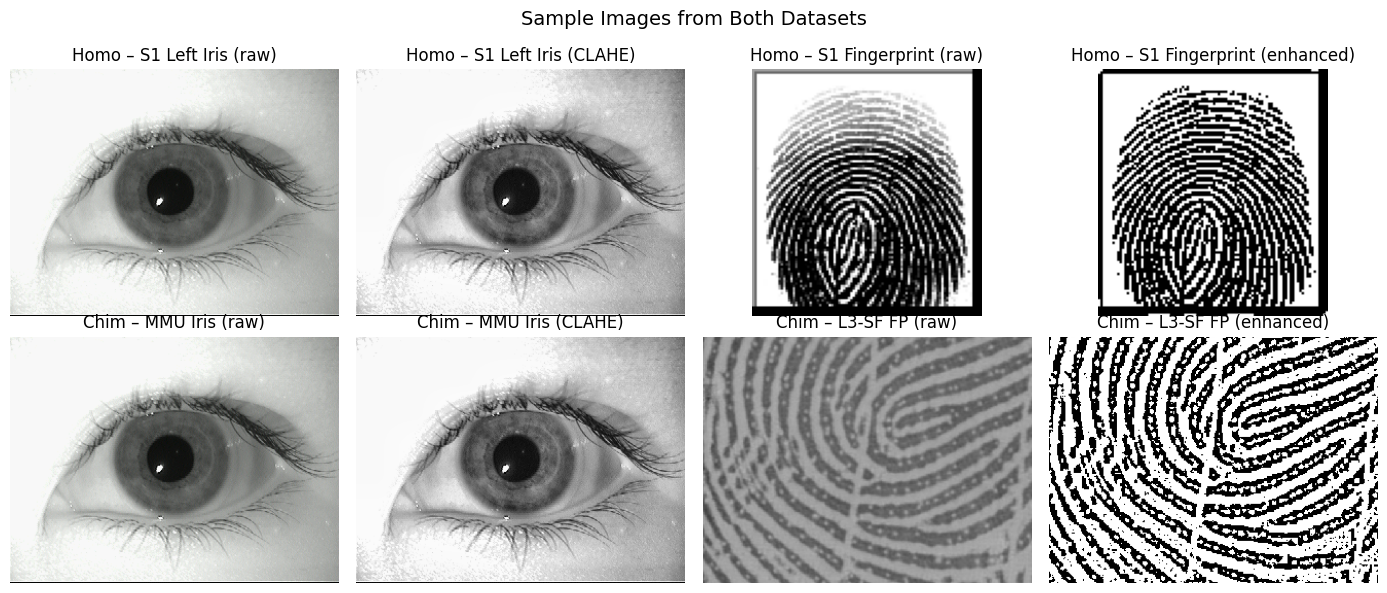

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Sample Images from Both Datasets", fontsize=14)

# Homologous — Subject 1
subj1_left_iris = glob_case_insensitive(
    os.path.join(HOMOLOGOUS_DIR, "1", "left"), "*.bmp")[0]
subj1_fp = glob_case_insensitive(
    os.path.join(HOMOLOGOUS_DIR, "1", "Fingerprint"), "*.bmp")[0]

axes[0, 0].imshow(cv2.cvtColor(cv2.imread(subj1_left_iris), cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Homo – S1 Left Iris (raw)")
axes[0, 1].imshow(cv2.cvtColor(preprocess_iris_img(subj1_left_iris), cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Homo – S1 Left Iris (CLAHE)")
axes[0, 2].imshow(cv2.cvtColor(cv2.imread(subj1_fp), cv2.COLOR_BGR2RGB))
axes[0, 2].set_title("Homo – S1 Fingerprint (raw)")
axes[0, 3].imshow(cv2.cvtColor(preprocess_fp_img(subj1_fp), cv2.COLOR_BGR2RGB))
axes[0, 3].set_title("Homo – S1 Fingerprint (enhanced)")

# Chimeric — Subject 1 (only if loaded)
if X_chim.shape[0] > 0:
    chim_iris = get_mmu_iris_paths(MMU_IRIS_DIR, 1)[0]
    chim_fp   = get_l3sf_fp_paths(L3SF_FP_DIR, L3SF_SUBFOLDERS, 1)[0]

    axes[1, 0].imshow(cv2.cvtColor(cv2.imread(chim_iris), cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title("Chim – MMU Iris (raw)")
    axes[1, 1].imshow(cv2.cvtColor(preprocess_iris_img(chim_iris), cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title("Chim – MMU Iris (CLAHE)")
    axes[1, 2].imshow(cv2.cvtColor(cv2.imread(chim_fp), cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title("Chim – L3-SF FP (raw)")
    axes[1, 3].imshow(cv2.cvtColor(preprocess_fp_img(chim_fp), cv2.COLOR_BGR2RGB))
    axes[1, 3].set_title("Chim – L3-SF FP (enhanced)")
else:
    for ax in axes[1]: ax.set_title("Chimeric data not available")

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

# CELL 9: PCA Dimensionality Reduction (on Homologous data)



Normalising features (StandardScaler) …
Applying PCA (retaining 98% variance) …
  Original dim  : 2560
  Reduced dim   : 372
  Variance kept : 98.00%


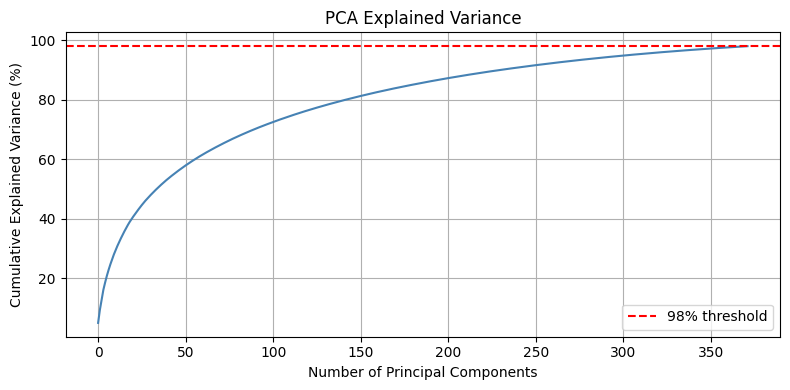

In [10]:

print("\nNormalising features (StandardScaler) …")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_homo)

print("Applying PCA (retaining 98% variance) …")
pca = PCA(n_components=0.98, svd_solver='full', random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"  Original dim  : {X_scaled.shape[1]}")
print(f"  Reduced dim   : {X_pca.shape[1]}")
print(f"  Variance kept : {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, color='steelblue')
plt.axhline(98, color='red', linestyle='--', label='98% threshold')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Explained Variance")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# CELL 10: Train / Test Split


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_homo,
    test_size=0.30,
    stratify=y_homo,
    random_state=RANDOM_SEED
)
print(f"Train samples: {X_train.shape[0]}")
print(f"Test  samples: {X_test.shape[0]}")

Train samples: 315
Test  samples: 135


# CELL 11: PSO-SVM — Fitness Function & Optimiser


2026-05-02 14:10:26,459 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}



Running PSO (15 particles × 30 iterations) …


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.54
2026-05-02 14:11:16,217 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.5396825396825398, best pos: [3.34350416e+02 1.32119818e-01]



  Best error rate  : 0.5397  →  CV accuracy ≈ 46.03%
  Optimal C        : 334.3504
  Optimal gamma    : 0.132120


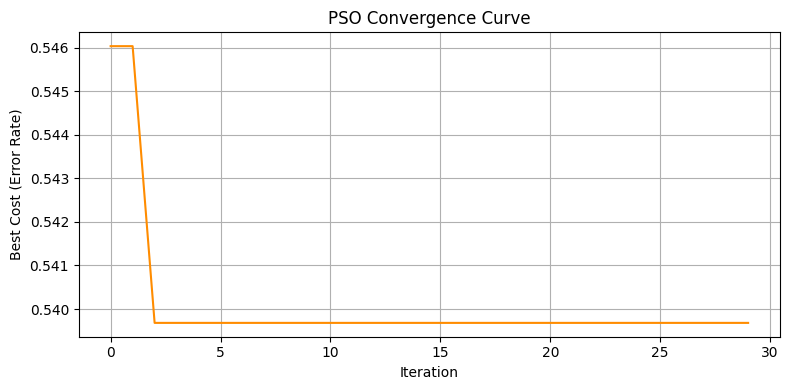

In [12]:
def svm_fitness(params: np.ndarray,
                X_tr: np.ndarray,
                y_tr: np.ndarray,
                cv: int = 3) -> np.ndarray:
    """
    PSO fitness function.
    params shape: (n_particles, 2)  → column 0 = C, column 1 = gamma
    Returns error rate (1 - accuracy) for each particle.
    """
    n_particles = params.shape[0]
    scores = np.zeros(n_particles)
    for i in range(n_particles):
        C_val     = float(params[i, 0])
        gamma_val = float(params[i, 1])
        model = SVC(kernel='rbf', C=C_val, gamma=gamma_val, random_state=RANDOM_SEED)
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy', n_jobs=-1)
        scores[i] = 1.0 - cv_scores.mean()   # PSO minimises → return error
    return scores


def optimise_svm_pso(X_tr, y_tr,
                      n_particles=15, n_iter=30, cv=3):
    """
    Run GlobalBest PSO to find optimal (C, gamma) for SVM-RBF.
    Search space: C ∈ [0.1, 1000],  gamma ∈ [1e-4, 1.0]
    """
    bounds = (np.array([0.1,  1e-4]),
              np.array([1000.0, 1.0]))

    options = {
        'c1': 0.5,   # cognitive weight (personal best)
        'c2': 0.3,   # social weight (global best)
        'w':  0.9    # inertia weight
    }

    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=2,
        options=options,
        bounds=bounds
    )

    print(f"\nRunning PSO ({n_particles} particles × {n_iter} iterations) …")
    cost, best_pos = optimizer.optimize(
        lambda p: svm_fitness(p, X_tr, y_tr, cv=cv),
        iters=n_iter,
        verbose=True
    )

    best_C     = best_pos[0]
    best_gamma = best_pos[1]
    print(f"\n  Best error rate  : {cost:.4f}  →  CV accuracy ≈ {(1-cost)*100:.2f}%")
    print(f"  Optimal C        : {best_C:.4f}")
    print(f"  Optimal gamma    : {best_gamma:.6f}")
    return best_C, best_gamma, optimizer


best_C, best_gamma, pso_optimizer = optimise_svm_pso(
    X_train, y_train,
    n_particles=15,
    n_iter=30,
    cv=3
)

# Plot PSO convergence
plt.figure(figsize=(8, 4))
plt.plot(pso_optimizer.cost_history, color='darkorange')
plt.xlabel("Iteration"); plt.ylabel("Best Cost (Error Rate)")
plt.title("PSO Convergence Curve")
plt.grid(True); plt.tight_layout(); plt.show()

# CELL 12: Train Final SVM with Optimised Parameters


In [13]:
print("\nTraining final SVM-RBF with PSO-optimised hyperparameters …")
final_svm = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma,
    probability=True,
    random_state=RANDOM_SEED
)
final_svm.fit(X_train, y_train)
print("  Training complete.")


Training final SVM-RBF with PSO-optimised hyperparameters …
  Training complete.


# CELL 13: Evaluation — Accuracy, FAR, FRR, Confusion Matrix



  FINAL TEST ACCURACY  : 77.04%
  Avg FAR (per class)  : 0.5219%
  Avg FRR (per class)  : 22.9630%
  Approx EER           : 11.7424%

Classification Report:
              precision    recall  f1-score   support

           1       0.60      1.00      0.75         3
           2       1.00      0.33      0.50         3
           3       0.00      0.00      0.00         3
           4       1.00      0.33      0.50         3
           5       0.60      1.00      0.75         3
           6       1.00      0.33      0.50         3
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3
          10       0.67      0.67      0.67         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       1.00      0.67      0.80         3
          14       1.00      1.00      1.00         3
          15       1.00      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


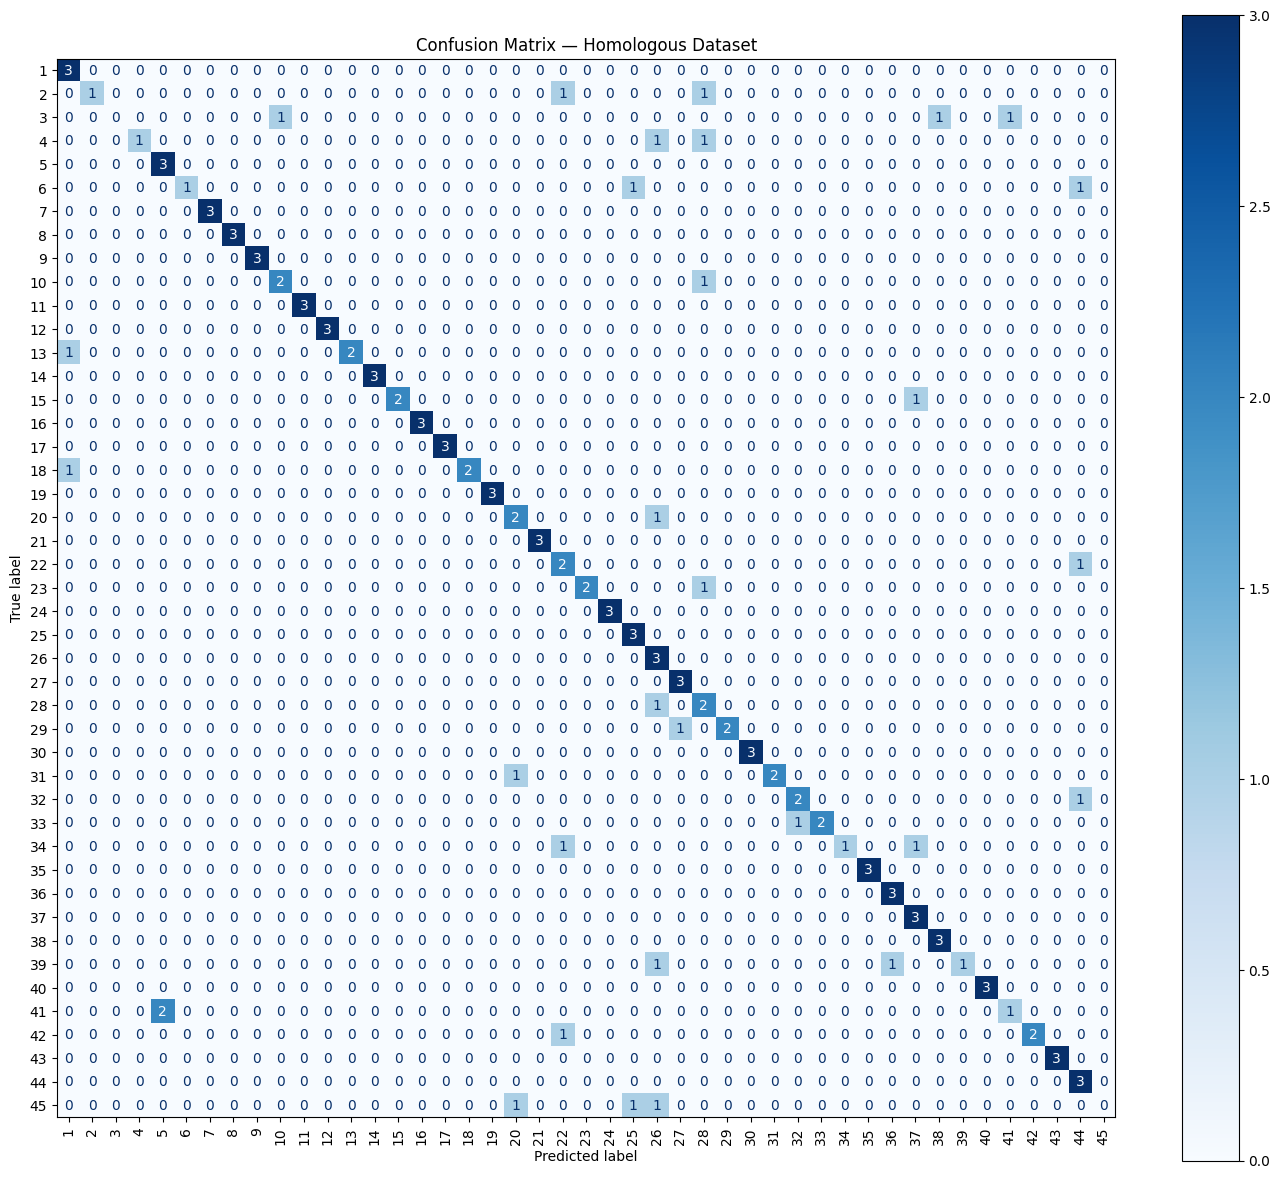

In [14]:
y_pred = final_svm.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_homo))
TP = np.diag(cm).astype(float)
FP = (cm.sum(axis=0) - TP).astype(float)
FN = (cm.sum(axis=1) - TP).astype(float)
TN = (cm.sum() - (TP + FP + FN)).astype(float)

# Avoid division by zero
FAR_per_class = np.where((FP + TN) > 0, FP / (FP + TN), 0.0)
FRR_per_class = np.where((FN + TP) > 0, FN / (FN + TP), 0.0)
EER_approx    = (FAR_per_class.mean() + FRR_per_class.mean()) / 2.0

print("\n" + "="*55)
print(f"  FINAL TEST ACCURACY  : {acc * 100:.2f}%")
print(f"  Avg FAR (per class)  : {FAR_per_class.mean() * 100:.4f}%")
print(f"  Avg FRR (per class)  : {FRR_per_class.mean() * 100:.4f}%")
print(f"  Approx EER           : {EER_approx * 100:.4f}%")
print("="*55)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=np.unique(y_homo))
disp.plot(ax=ax, xticks_rotation=90, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Homologous Dataset")
plt.tight_layout(); plt.show()

# CELL 14: Cross-Dataset Validation with Chimeric Data


In [15]:
if X_chim.shape[0] > 0:
    print("\n" + "="*55)
    print("Cross-dataset validation on CHIMERIC data …")
    print("="*55)

    X_chim_scaled = scaler.transform(X_chim)
    X_chim_pca    = pca.transform(X_chim_scaled)

    # Re-map chimeric labels (101-145) to 1-45 for fair comparison
    y_chim_mapped = y_chim - 100

    # Predict on chimeric data using the trained SVM
    y_chim_pred = final_svm.predict(X_chim_pca)

    # Accuracy: how many chimeric subjects are correctly identified?
    chim_acc = accuracy_score(y_chim_mapped, y_chim_pred)
    print(f"\n  Chimeric Test Accuracy: {chim_acc * 100:.2f}%")
    print("  (Note: lower accuracy expected — different sensors/populations)")
else:
    print("\n[SKIP] Chimeric validation skipped — no chimeric data loaded.")
    chim_acc = 0.0


Cross-dataset validation on CHIMERIC data …

  Chimeric Test Accuracy: 1.14%
  (Note: lower accuracy expected — different sensors/populations)


# CELL 15: Save Results Summary


In [16]:
import json, datetime

results = {
    "timestamp"         : datetime.datetime.now().isoformat(),
    "pso_best_C"        : round(best_C, 4),
    "pso_best_gamma"    : round(best_gamma, 6),
    "homologous_acc_pct": round(acc * 100, 2),
    "avg_FAR_pct"       : round(FAR_per_class.mean() * 100, 4),
    "avg_FRR_pct"       : round(FRR_per_class.mean() * 100, 4),
    "approx_EER_pct"    : round(EER_approx * 100, 4),
    "chimeric_acc_pct"  : round(chim_acc * 100, 2),
    "pca_components"    : int(X_pca.shape[1]),
    "train_samples"     : int(X_train.shape[0]),
    "test_samples"      : int(X_test.shape[0]),
}

save_path = "/content/drive/MyDrive/IRIS-FINGERPRINT-PSO-SVM/results_summary.json"
with open(save_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to: {save_path}")
print(json.dumps(results, indent=2))



Results saved to: /content/drive/MyDrive/IRIS-FINGERPRINT-PSO-SVM/results_summary.json
{
  "timestamp": "2026-05-02T14:11:20.453555",
  "pso_best_C": 334.3504,
  "pso_best_gamma": 0.13212,
  "homologous_acc_pct": 77.04,
  "avg_FAR_pct": 0.5219,
  "avg_FRR_pct": 22.963,
  "approx_EER_pct": 11.7424,
  "chimeric_acc_pct": 1.14,
  "pca_components": 372,
  "train_samples": 315,
  "test_samples": 135
}
